In [1]:
import pandas as pd

In [2]:
import sys, importlib
# sys.path.append('/mnt/data')
import tcrempnet_utils as utils
importlib.reload(utils)
print('utils loaded; available:', len([n for n in dir(utils) if callable(getattr(utils, n, None))]))

/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


utils loaded; available: 51


In [3]:
import sys
sys.path.append('/home/evlasova/mirpy')
from mir.common.clonotype_dataset import ClonotypeDataset
from mir.common.clonotype import ClonotypeAA
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
DATA_PATH = '/projects/immunestatus/vdjdb'

In [6]:
info = pd.read_csv(f'{DATA_PATH}/tcrempnet_YLQPRTFLL/trb_vdjdb_YLQPRTFLL_summary_tcrempnet.tsv', sep='\t')

In [7]:
info

,cluster_id,cluster_size,sample,background,enrichment_pvalue_zbinom,enrichment_fdr_zbinom,log_fold_change
0,0,642,73,569,0.000000,0.000000,2.408540
1,1,388,32,356,0.000000,0.000000,2.254029
2,2,389,1,388,0.067564,0.969128,0.711497
3,3,79,9,70,0.000000,0.000000,2.409473
4,4,205,64,141,0.000000,0.000000,2.957290
...,...,...,...,...,...,...,...
20704,20704,3,0,3,0.969081,0.969128,-6.176792
20705,20705,3,0,3,0.969081,0.969128,-6.176792
20706,20706,3,0,3,0.969081,0.969128,-6.176792
20707,20707,3,0,3,0.969081,0.969128,-6.176792


In [79]:
info[info.log_fold_change > 0].cluster_id

0            0
1            1
2            2
3            3
4            4
         ...  
16908    16908
19523    19523
19542    19542
19595    19595
20420    20420
Name: cluster_id, Length: 176, dtype: int64

In [28]:
info.sort_values(by='cluster_size')

,cluster_id,cluster_size,sample,background,enrichment_pvalue_zbinom,enrichment_fdr_zbinom,log_fold_change
14667,14667,3,0,3,0.969081,0.969128,-6.176792
14708,14708,3,0,3,0.969081,0.969128,-6.176792
14691,14691,3,0,3,0.969081,0.969128,-6.176792
14692,14692,3,0,3,0.969081,0.969128,-6.176792
14694,14694,3,0,3,0.969081,0.969128,-6.176792
...,...,...,...,...,...,...,...
85,85,37518,3,37515,0.000238,0.042926,-0.796755
165,165,37983,2,37981,0.000082,0.015498,-0.978207
23,23,49886,17,49869,0.106415,0.969128,-0.167053
77,77,53934,8,53926,0.000212,0.038905,-0.528379


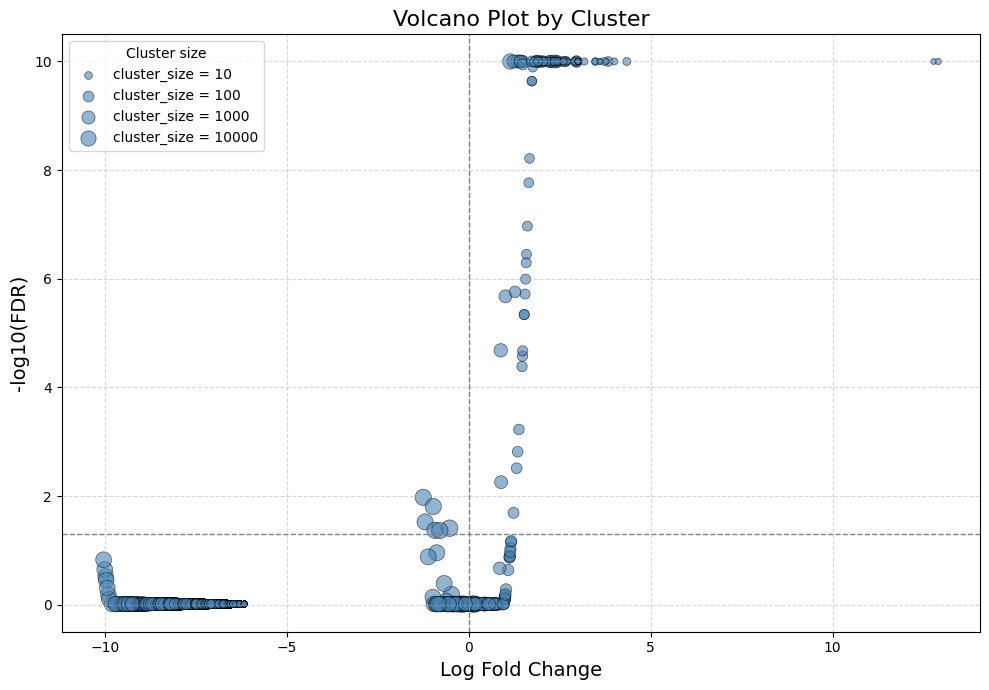

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Копия датафрейма
df = info.copy()
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["enrichment_fdr_zbinom", "log_fold_change"])

# === Параметры ===
x = df["log_fold_change"]
y = -np.log10(df["enrichment_fdr_zbinom"] + 1e-10)
sizes = np.log10(df["cluster_size"] + 1) * 30

# === Построение ===
plt.figure(figsize=(10, 7))
plt.scatter(x, y, s=sizes, c="steelblue", alpha=0.6, edgecolors="black", linewidths=0.5)

# === Оформление ===
plt.xlabel("Log Fold Change", fontsize=14)
plt.ylabel("-log10(FDR)", fontsize=14)
plt.title("Volcano Plot by Cluster", fontsize=16)
plt.axhline(y=-np.log10(0.05), color="gray", linestyle="--", linewidth=1)
plt.axvline(x=0, color="gray", linestyle="--", linewidth=1)
plt.grid(True, linestyle="--", alpha=0.5)

# === Легенда по размерам кластера ===
# Берём несколько характерных значений для легенды
legend_sizes = [10, 100, 1000, 10000]
legend_handles = [
    plt.scatter([], [], s=np.log10(s + 1) * 30, color="steelblue", alpha=0.6, edgecolors="black", linewidths=0.5)
    for s in legend_sizes
]
plt.legend(
    legend_handles,
    [f"cluster_size = {s}" for s in legend_sizes],
    title="Cluster size",
    loc="best",
    frameon=True
)

plt.tight_layout()
plt.show()


In [81]:
enriched = pd.read_csv(f'{DATA_PATH}/tcrempnet_YLQPRTFLL/trb_vdjdb_YLQPRTFLL_enriched_clonotypes_tcremp.tsv', sep='\t')
enriched

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,source,enrichment_pvalue_zbinom
0,s_3863,0,CSARDEKATNTGELFF,TRBV20-1*01,TRBJ2-2*01,sample,0.0
1,s_6163,0,CSARTPMGQNTGELFF,TRBV20-1*01,TRBJ2-2*01,sample,0.0
2,s_6177,0,CSARDLAGMNTGELFF,TRBV20-1*01,TRBJ2-2*01,sample,0.0
3,s_6181,0,CSARDAGGQNTGELFF,TRBV20-1*01,TRBJ2-2*01,sample,0.0
4,s_6209,0,CSARDQASQNTGELFF,TRBV20-1*01,TRBJ2-2*01,sample,0.0
...,...,...,...,...,...,...,...
255940,b_1611767,210,CAIWTGGNEQFF,TRBV7-9*01,TRBJ2-1*01,background,0.0
255941,b_1833514,210,CAGTWGGPEQFF,TRBV7-9*01,TRBJ2-1*01,background,0.0
255942,s_102971,211,CASRHMGTGFYNEQFF,TRBV28*01,TRBJ2-1*01,sample,0.0
255943,b_1338003,211,CATHSTGWGAYNEQFF,TRBV28*01,TRBJ2-1*01,background,0.0


In [83]:
enriched = enriched[enriched.cluster_id.isin(info[info.log_fold_change > 0].cluster_id)]

In [84]:
enriched.cluster_id.value_counts()

cluster_id
6        11375
55        1330
11         947
20         939
13         830
         ...  
19542        3
88           3
22           3
210          3
211          3
Name: count, Length: 109, dtype: int64

In [85]:
vdjdb_init = pd.read_csv('/projects/immunestatus/vdjdb/vdjdb-2025-07-30/vdjdb_full_filtered.txt', sep='\t')
vdjdb_init

/scratch/ipykernel_46971/928325651.py:1: DtypeWarning: Columns (5,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30) have mixed types. Specify dtype option on import or set low_memory=False.
  vdjdb_init = pd.read_csv('/projects/immunestatus/vdjdb/vdjdb-2025-07-30/vdjdb_full_filtered.txt', sep='\t')


,cdr3.alpha,v.alpha,j.alpha,cdr3.beta,v.beta,d.beta,j.beta,species,mhc.a,mhc.b,...,meta.replica.id,meta.clone.id,meta.epitope.id,meta.tissue,meta.donor.MHC,meta.donor.MHC.method,meta.structure.id,cdr3fix.alpha,cdr3fix.beta,vdjdb.score
0,NaN,NaN,NaN,CASSIVGGNEQFF,TRBV19*01,NaN,TRBJ2-1*01,HomoSapiens,HLA-A*02:01,B2M,...,NaN,NaN,M158–66,PBMC,"A02,A03,B07,B27,C01,C07",NaN,NaN,NaN,"{'cdr3': 'CASSIVGGNEQFF', 'cdr3_old': 'CASSIVG...",3
1,NaN,NaN,NaN,CASSMRSTGELFF,TRBV19*01,NaN,TRBJ2-2*01,HomoSapiens,HLA-A*02:01,B2M,...,NaN,NaN,M158–66,PBMC,"A02,A03,B07,B27,C01,C07",NaN,NaN,NaN,"{'cdr3': 'CASSMRSTGELFF', 'cdr3_old': 'CASSMRS...",3
2,NaN,NaN,NaN,CASSIRSAWAQYF,TRBV19*01,NaN,TRBJ2-3*01,HomoSapiens,HLA-A*02:01,B2M,...,NaN,NaN,M158–66,PBMC,"A02,A03,B07,B27,C01,C07",NaN,NaN,NaN,"{'cdr3': 'CASSIRSAWAQYF', 'cdr3_old': 'CASSIRS...",2
3,NaN,NaN,NaN,CASSQRSTGELFF,TRBV19*01,NaN,TRBJ2-2*01,HomoSapiens,HLA-A*02:01,B2M,...,NaN,NaN,M158–66,PBMC,"A02,A03,B07,B27,C01,C07",NaN,NaN,NaN,"{'cdr3': 'CASSQRSTGELFF', 'cdr3_old': 'CASSQRS...",2
4,NaN,NaN,NaN,CASSIRSSYEQYF,TRBV19*01,NaN,TRBJ2-7*01,HomoSapiens,HLA-A*02:01,B2M,...,NaN,NaN,M158–66,PBMC,"A02,A03,B07,B27,C01,C07",NaN,NaN,NaN,"{'cdr3': 'CASSIRSSYEQYF', 'cdr3_old': 'CASSIRS...",3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107954,NaN,NaN,NaN,CASSPSARGNQPQHF,TRBV2*01,TRBD1*01,TRBJ1-5*01,HomoSapiens,HLA-DRA*01:01,HLA-DRB5*01:01,...,NaN,NaN,NaN,NaN,"DRB1*0102,DRB1*1101",INNO-LiPA HLA-DRB1 Plus kit,NaN,NaN,"{'cdr3': 'CASSPSARGNQPQHF', 'cdr3_old': 'CASSP...",0
107955,NaN,NaN,NaN,CASSVGTSGVGEQYF,TRBV2*01,TRBD2*01,TRBJ2-7*01,HomoSapiens,HLA-DRA*01:01,HLA-DRB5*01:01,...,NaN,NaN,NaN,NaN,"DRB1*0102,DRB1*1101",INNO-LiPA HLA-DRB1 Plus kit,NaN,NaN,"{'cdr3': 'CASSVGTSGVGEQYF', 'cdr3_old': 'CASSV...",0
107956,NaN,NaN,NaN,CASSALASGGDTQYF,TRBV2*01,TRBD2*01,TRBJ2-3*01,HomoSapiens,HLA-DRA*01:01,HLA-DRB1*15:02,...,NaN,NaN,NaN,NaN,"DRB1*0701/ 0703/0704/ 0705/ 0706,DRB1*1501/ 15...",INNO-LiPA HLA-DRB1 Plus kit,NaN,NaN,"{'cdr3': 'CASSALASGGDTQYF', 'cdr3_old': 'CASSA...",0
107957,NaN,NaN,NaN,CASSRLAGGMDEQFF,TRBV2*01,TRBD2*02,TRBJ2-1*01,HomoSapiens,HLA-DRA*01:01,HLA-DRB1*15:02,...,NaN,NaN,NaN,NaN,"DRB1*0701/ 0703/0704/ 0705/ 0706,DRB1*1501/ 15...",INNO-LiPA HLA-DRB1 Plus kit,NaN,NaN,"{'cdr3': 'CASSRLAGGMDEQFF', 'cdr3_old': 'CASSR...",3


In [86]:
enriched = enriched[enriched.source == 'sample']

In [87]:
enriched['vdjdb_id'] = enriched.clone_id.apply(lambda x: int(x[2:]))

In [88]:
enriched

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,source,enrichment_pvalue_zbinom,vdjdb_id
0,s_3863,0,CSARDEKATNTGELFF,TRBV20-1*01,TRBJ2-2*01,sample,0.000000e+00,3863
1,s_6163,0,CSARTPMGQNTGELFF,TRBV20-1*01,TRBJ2-2*01,sample,0.000000e+00,6163
2,s_6177,0,CSARDLAGMNTGELFF,TRBV20-1*01,TRBJ2-2*01,sample,0.000000e+00,6177
3,s_6181,0,CSARDAGGQNTGELFF,TRBV20-1*01,TRBJ2-2*01,sample,0.000000e+00,6181
4,s_6209,0,CSARDQASQNTGELFF,TRBV20-1*01,TRBJ2-2*01,sample,0.000000e+00,6209
...,...,...,...,...,...,...,...,...
255837,s_102817,198,CASTSRQVHEKLFF,TRBV19*01,TRBJ1-4*01,sample,4.753573e-10,102817
255887,s_102845,200,CASSPSGTSTGELFF,TRBV27*01,TRBJ2-2*01,sample,7.453549e-11,102845
255933,s_102929,205,CATGPGQGDYGYTF,TRBV15*01,TRBJ1-2*01,sample,0.000000e+00,102929
255939,s_102963,210,CASLFGGHEQFF,TRBV7-9*01,TRBJ2-1*01,sample,0.000000e+00,102963


In [89]:
merged_data = vdjdb_init.reset_index().rename(columns={'index': 'vdjdb_id'}).merge(enriched)
merged_data.groupby('cluster_id').nunique()['antigen.epitope']

cluster_id
0        1
1        1
3        1
4        1
6        1
        ..
16908    1
19523    1
19542    1
19595    1
20420    1
Name: antigen.epitope, Length: 109, dtype: int64

In [90]:
merged_data[merged_data.cluster_id == 1]#['antigen.epitope']

,vdjdb_id,cdr3.alpha,v.alpha,j.alpha,cdr3.beta,v.beta,d.beta,j.beta,species,mhc.a,...,cdr3fix.alpha,cdr3fix.beta,vdjdb.score,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,source,enrichment_pvalue_zbinom
1,3864,CVVNRDNDMRF,TRAV12-1*01,TRAJ43*01,CASMEENTGELFF,TRBV5-1*01,NaN,TRBJ2-2*01,HomoSapiens,HLA-A*02:01,...,"{'cdr3': 'CVVNRDNDMRF', 'cdr3_old': 'CVVNRDNDM...","{'cdr3': 'CASMEENTGELFF', 'cdr3_old': 'CASMEEN...",0,s_3864,1,CASMEENTGELFF,TRBV5-1*01,TRBJ2-2*01,sample,0.0
5,3870,CVVNGMNDMRF,TRAV12-1*01,TRAJ43*01,CAAGDANTGELFF,TRBV5-1*01,NaN,TRBJ2-2*01,HomoSapiens,HLA-A*02:01,...,"{'cdr3': 'CVVNGMNDMRF', 'cdr3_old': 'CVVNGMNDM...","{'cdr3': 'CAAGDANTGELFF', 'cdr3_old': 'CAAGDAN...",0,s_3870,1,CAAGDANTGELFF,TRBV5-1*01,TRBJ2-2*01,sample,0.0
24,6186,CVVNNNNDMRF,TRAV12-1*01,TRAJ43*01,CASNEENTGELFF,TRBV5-1*01,NaN,TRBJ2-2*01,HomoSapiens,HLA-A*02:01,...,"{'cdr3': 'CVVNNNNDMRF', 'cdr3_old': 'CVVNNNNDM...","{'cdr3': 'CASNEENTGELFF', 'cdr3_old': 'CASNEEN...",0,s_6186,1,CASNEENTGELFF,TRBV5-1*01,TRBJ2-2*01,sample,0.0
41,6287,CVVNMQDDMRF,TRAV12-1*01,TRAJ43*01,CASQDSNTGELFF,TRBV5-1*01,NaN,TRBJ2-2*01,HomoSapiens,HLA-A*02:01,...,"{'cdr3': 'CVVNMQDDMRF', 'cdr3_old': 'CVVNMQDDM...","{'cdr3': 'CASQDSNTGELFF', 'cdr3_old': 'CASQDSN...",0,s_6287,1,CASQDSNTGELFF,TRBV5-1*01,TRBJ2-2*01,sample,0.0
63,6470,NaN,NaN,NaN,CASQTLNTGELFF,TRBV5-1*01,NaN,TRBJ2-2*01,HomoSapiens,HLA-A*02:01,...,NaN,"{'cdr3': 'CASQTLNTGELFF', 'cdr3_old': 'CASQTLN...",0,s_6470,1,CASQTLNTGELFF,TRBV5-1*01,TRBJ2-2*01,sample,0.0
87,22012,NaN,NaN,NaN,CATSDSNTGELFF,TRBV5-1*01,NaN,TRBJ2-2*01,HomoSapiens,HLA-A*02:01,...,NaN,"{'cdr3': 'CATSDSNTGELFF', 'cdr3_old': 'CATSDSN...",0,s_22012,1,CATSDSNTGELFF,TRBV5-1*01,TRBJ2-2*01,sample,0.0
108,22045,NaN,NaN,NaN,CASGDENTGELFF,TRBV5-1*01,NaN,TRBJ2-2*01,HomoSapiens,HLA-A*02:01,...,NaN,"{'cdr3': 'CASGDENTGELFF', 'cdr3_old': 'CASGDEN...",0,s_22045,1,CASGDENTGELFF,TRBV5-1*01,TRBJ2-2*01,sample,0.0
144,22107,NaN,NaN,NaN,CASSGLNTGELFF,TRBV5-1*01,NaN,TRBJ2-2*01,HomoSapiens,HLA-A*02:01,...,NaN,"{'cdr3': 'CASSGLNTGELFF', 'cdr3_old': 'CASSGLN...",0,s_22107,1,CASSGLNTGELFF,TRBV5-1*01,TRBJ2-2*01,sample,0.0
277,99502,CVVNRNNDMRF,TRAV12-1*01,TRAJ43*01,CASMDENTGELFF,TRBV5-1*01,NaN,TRBJ2-2*01,HomoSapiens,HLA-A*02:01,...,"{'cdr3': 'CVVNRNNDMRF', 'cdr3_old': 'CVVNRNNDM...","{'cdr3': 'CASMDENTGELFF', 'cdr3_old': 'CASMDEN...",0,s_99502,1,CASMDENTGELFF,TRBV5-1*01,TRBJ2-2*01,sample,0.0
289,99558,CVVNKEDDMRF,TRAV12-1*01,TRAJ43*01,CASTETNTGELFF,TRBV5-1*01,NaN,TRBJ2-2*01,HomoSapiens,HLA-A*02:01,...,"{'cdr3': 'CVVNKEDDMRF', 'cdr3_old': 'CVVNKEDDM...","{'cdr3': 'CASTETNTGELFF', 'cdr3_old': 'CASTETN...",0,s_99558,1,CASTETNTGELFF,TRBV5-1*01,TRBJ2-2*01,sample,0.0


In [91]:
motifs = pd.read_csv('/projects/immunestatus/vdjdb/vdjdb-2025-07-30/cluster_members.txt', sep='\t')
motifs

,species,antigen.epitope,antigen.gene,antigen.species,mhc.a,mhc.b,mhc.class,gene,cdr3aa,x,y,cid,csz,v.segm,j.segm,v.end,j.start,v.segm.repr,j.segm.repr
0,HomoSapiens,ALSKGVHFV,ORF3,SARS-CoV-2,HLA-A*02:01,B2M,MHCI,TRB,CASSLSGDDYNEQFF,102.447143,32.107434,H.B.ALSKGVHFV.1,5,TRBV27*01,TRBJ2-1*01,5,9,TRBV27*01,TRBJ2-1*01
1,HomoSapiens,ALSKGVHFV,ORF3,SARS-CoV-2,HLA-A*02:01,B2M,MHCI,TRB,CASSLAGDDYNEQFF,36.799698,2.795705,H.B.ALSKGVHFV.1,5,TRBV27*01,TRBJ2-1*01,5,9,TRBV27*01,TRBJ2-1*01
2,HomoSapiens,ALSKGVHFV,ORF3,SARS-CoV-2,HLA-A*02:01,B2M,MHCI,TRB,CASSLAGDNYNEQFF,3.568838,-52.141266,H.B.ALSKGVHFV.1,5,TRBV27*01,TRBJ2-1*01,5,9,TRBV27*01,TRBJ2-1*01
3,HomoSapiens,ALSKGVHFV,ORF3,SARS-CoV-2,HLA-A*02:01,B2M,MHCI,TRB,CASSLAGDSYNEQFF,-36.541775,-2.006452,H.B.ALSKGVHFV.1,5,TRBV27*01,TRBJ2-1*01,5,8,TRBV27*01,TRBJ2-1*01
4,HomoSapiens,ALSKGVHFV,ORF3,SARS-CoV-2,HLA-A*02:01,B2M,MHCI,TRB,CASSLVGDSYNEQFF,-105.450820,18.494963,H.B.ALSKGVHFV.1,5,TRBV27*01,TRBJ2-1*01,5,8,TRBV27*01,TRBJ2-1*01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35563,MusMusculus,TVYGFCLL,m139,MCMV,H-2Kb,B2M,MHCI,TRA,CAASENYNQGKLIF,308.410316,128.603566,M.A.TVYGFCLL.2,12,"TRAV7-4*01,TRAV7D-4*01",TRAJ23*01,5,5,TRAV12D-1*01,TRAJ23*01
35564,MusMusculus,TVYGFCLL,m139,MCMV,H-2Kb,B2M,MHCI,TRA,CALIMNYNQGKLIF,187.064152,-192.603423,M.A.TVYGFCLL.2,12,TRAV12D-1*01,TRAJ23*01,3,5,TRAV12D-1*01,TRAJ23*01
35565,MusMusculus,TVYGFCLL,m139,MCMV,H-2Kb,B2M,MHCI,TRA,CALIPNYNQGKLIF,267.595691,-180.697136,M.A.TVYGFCLL.2,12,TRAV12D-1*01,TRAJ23*01,3,5,TRAV12D-1*01,TRAJ23*01
35566,MusMusculus,TVYGFCLL,m139,MCMV,H-2Kb,B2M,MHCI,TRA,CALRENYNQGKLIF,242.143769,-43.271264,M.A.TVYGFCLL.2,12,TRAV12-3*01,TRAJ23*01,3,5,TRAV12D-1*01,TRAJ23*01


In [92]:
motifs[motifs['antigen.epitope'].str.startswith('YLQ')][['cdr3aa', 'v.segm', 'j.segm', 'antigen.epitope']]

,cdr3aa,v.segm,j.segm,antigen.epitope
33739,CVVNMETDKLIF,TRAV12-1*01,TRAJ34*01,YLQPRTFLL
33740,CVVNMENDMRF,TRAV12-1*01,TRAJ43*01,YLQPRTFLL
33741,CASQDTNTGELFF,TRBV2*01,TRBJ2-2*01,YLQPRTFLL
33742,CASQEANTGELFF,"TRBV19*01,TRBV4-3*01",TRBJ2-2*01,YLQPRTFLL
33743,CASQELDTGELFF,TRBV2*01,TRBJ2-2*01,YLQPRTFLL
...,...,...,...,...
34297,CATTDLNTGELFF,TRBV15*01,TRBJ2-2*01,YLQPRTFLL
34298,CSARDALAQNTGELFF,TRBV20-1*01,TRBJ2-2*01,YLQPRTFLL
34299,CSARDDRALNTGELFF,TRBV20-1*01,TRBJ2-2*01,YLQPRTFLL
34300,CSARDDRAQNTGELFF,TRBV20-1*01,TRBJ2-2*01,YLQPRTFLL


In [93]:
vdjdb_tcrnet = motifs[motifs['antigen.epitope'].str.startswith('YLQ')][['cdr3aa', 'v.segm', 'j.segm', 'antigen.epitope']]
vdjdb_tcrnet

,cdr3aa,v.segm,j.segm,antigen.epitope
33739,CVVNMETDKLIF,TRAV12-1*01,TRAJ34*01,YLQPRTFLL
33740,CVVNMENDMRF,TRAV12-1*01,TRAJ43*01,YLQPRTFLL
33741,CASQDTNTGELFF,TRBV2*01,TRBJ2-2*01,YLQPRTFLL
33742,CASQEANTGELFF,"TRBV19*01,TRBV4-3*01",TRBJ2-2*01,YLQPRTFLL
33743,CASQELDTGELFF,TRBV2*01,TRBJ2-2*01,YLQPRTFLL
...,...,...,...,...
34297,CATTDLNTGELFF,TRBV15*01,TRBJ2-2*01,YLQPRTFLL
34298,CSARDALAQNTGELFF,TRBV20-1*01,TRBJ2-2*01,YLQPRTFLL
34299,CSARDDRALNTGELFF,TRBV20-1*01,TRBJ2-2*01,YLQPRTFLL
34300,CSARDDRAQNTGELFF,TRBV20-1*01,TRBJ2-2*01,YLQPRTFLL


In [94]:
tcrvdb = pd.read_csv('../../data/01_05_2025_TCRvdb.csv').drop(columns=['Unnamed: 0']).dropna(subset=['padj'])
tcrvdb[['cdr3_beta_aa', 'TRBV', 'TRBJ', 'epitope_aa', 'padj']]

,cdr3_beta_aa,TRBV,TRBJ,epitope_aa,padj
0,CATGGDHNTGELFF,TRBV2,TRBJ2-2,YLQPRTFLL,1.636410e-40
1,CSARDPSGVKLFF,TRBV20-1,TRBJ1-4,YLQPRTFLL,5.774793e-03
2,CASSYRGTGLNEQFF,TRBV6-2,TRBJ2-1,YLQPRTFLL,1.000000e+00
3,CASSLAGSSYNSPLHF,TRBV7-8,TRBJ1-6,YLQPRTFLL,1.296120e-01
4,CATQSDPNTGELFF,TRBV2,TRBJ2-2,YLQPRTFLL,6.701844e-56
...,...,...,...,...,...
631,CSARDGTGNGYTF,TRBV20-1,TRBJ1-2,GLCTLVAML,4.228298e-01
632,CASSQSPGGTQYF,TRBV14,TRBJ2-3,GLCTLVAML,1.481753e-86
633,CSARDSTGNGYTF,TRBV20-1*01,TRBJ1-2*01,GLCTLVAML,5.187643e-01
634,CASSQSPGGVAFF,TRBV16S1,TRBJ1S1,GLCTLVAML,1.000000e+00


In [95]:
tcrvdb['valid'] = tcrvdb.padj < 10**-5 

In [96]:
tcrvdb[tcrvdb.epitope_aa.str.startswith('YLQ')]

,name,clonotype_aa,cdr3_alpha_aa,cdr3_beta_aa,TRAV,TRAJ,TRBV,TRBJ,TRBD,TRAV_IMGT,...,hla_long,data_origin,vdjdb_score,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,valid
0,1_5_H3_86_YLQPRTFLL,TRAV12-1_CVVNIDTDKLIF_TRAJ34--TRBV2_CATGGDHNTG...,CVVNIDTDKLIF,CATGGDHNTGELFF,TRAV12-1,TRAJ34,TRBV2,TRBJ2-2,NaN,TRAV12-1*01,...,A*02:01,vdjdb,0.0,198.217526,-2.653196,0.188261,-13.561965,6.730858e-42,1.636410e-40,True
1,1_6_G24_179_YLQPRTFLL,TRAV5_CAEILDFGNEKLTF_TRAJ48--TRBV20-1_CSARDPSG...,CAEILDFGNEKLTF,CSARDPSGVKLFF,TRAV5,TRAJ48,TRBV20-1,TRBJ1-4,NaN,TRAV5*01,...,A*02:01,vdjdb,1.0,48.227439,-1.112206,0.302166,-3.349832,8.086058e-04,5.774793e-03,False
2,1_6_H1_84_YLQPRTFLL,TRAV35_CAAMNYGGSQGNLIF_TRAJ42--TRBV6-2_CASSYRG...,CAAMNYGGSQGNLIF,CASSYRGTGLNEQFF,TRAV35,TRAJ42,TRBV6-2,TRBJ2-1,NaN,TRAV35*01,...,A*02:01,vdjdb,0.0,77.593373,0.206727,0.238408,0.447668,6.543928e-01,1.000000e+00,False
3,1_6_H2_85_YLQPRTFLL,TRAV21_CAVKDTDKLIF_TRAJ34--TRBV7-8_CASSLAGSSYN...,CAVKDTDKLIF,CASSLAGSSYNSPLHF,TRAV21,TRAJ34,TRBV7-8,TRBJ1-6,NaN,TRAV21*01,...,A*02:01,vdjdb,0.0,21.861277,1.116579,0.451138,2.253366,2.423609e-02,1.296120e-01,False
4,1_6_H3_86_YLQPRTFLL,TRAV12-1_CVVNRNNDMRF_TRAJ43--TRBV2_CATQSDPNTGE...,CVVNRNNDMRF,CATQSDPNTGELFF,TRAV12-1,TRAJ43,TRBV2,TRBJ2-2,NaN,TRAV12-1*01,...,A*02:01,vdjdb,0.0,251.554645,-2.851169,0.172124,-15.983631,1.661776e-57,6.701844e-56,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
435,1_6_C19_126_YLQPRTFLL,TRAV19_CALSEASTGNQFYF_TRAJ49--TRBV20-1_CSASRGG...,CALSEASTGNQFYF,CSASRGGALYNEQFF,TRAV19,TRAJ49,TRBV20-1,TRBJ2-1,TRBD2,TRAV19*01,...,A*02:01,vdjdb,0.0,28.712481,0.088951,0.364827,0.000000,1.000000e+00,1.000000e+00,False
436,1_6_C20_127_YLQPRTFLL,TRAV12-1_CVVNNNNDMRF_TRAJ43--TRBV12-3_CARGDANT...,CVVNNNNDMRF,CARGDANTGELFF,TRAV12-1,TRAJ43,TRBV12-3,TRBJ2-2,NaN,TRAV12-1*01,...,A*02:01,vdjdb,0.0,184.810662,-2.425191,0.190807,-12.186085,3.687152e-34,7.181566e-33,True
437,1_6_C18_125_YLQPRTFLL,TRAV35_CAGQRGGADGLTF_TRAJ45--TRBV13_CASSLAAAYE...,CAGQRGGADGLTF,CASSLAAAYEQYF,TRAV35,TRAJ45,TRBV13,TRBJ2-7,TRBD1,TRAV35*01,...,A*02:01,vdjdb,0.0,40.502523,-0.369620,0.318511,-0.846502,3.972728e-01,9.392174e-01,False
438,1_6_C3_26_YLQPRTFLL,TRAV4_CLVGENFNKFYF_TRAJ21--TRBV5-1_CASSLGQSLEQ...,CLVGENFNKFYF,CASSLGQSLEQYF,TRAV4,TRAJ21,TRBV5-1,TRBJ2-7,NaN,TRAV4*01,...,A*02:01,vdjdb,0.0,363.670607,-0.153974,0.137708,-0.391947,6.950970e-01,1.000000e+00,False


In [97]:
tcrvdb[['cdr3_beta_aa', 'TRBV', 'TRBJ', 'epitope_aa', 'valid']]

,cdr3_beta_aa,TRBV,TRBJ,epitope_aa,valid
0,CATGGDHNTGELFF,TRBV2,TRBJ2-2,YLQPRTFLL,True
1,CSARDPSGVKLFF,TRBV20-1,TRBJ1-4,YLQPRTFLL,False
2,CASSYRGTGLNEQFF,TRBV6-2,TRBJ2-1,YLQPRTFLL,False
3,CASSLAGSSYNSPLHF,TRBV7-8,TRBJ1-6,YLQPRTFLL,False
4,CATQSDPNTGELFF,TRBV2,TRBJ2-2,YLQPRTFLL,True
...,...,...,...,...,...
631,CSARDGTGNGYTF,TRBV20-1,TRBJ1-2,GLCTLVAML,False
632,CASSQSPGGTQYF,TRBV14,TRBJ2-3,GLCTLVAML,True
633,CSARDSTGNGYTF,TRBV20-1*01,TRBJ1-2*01,GLCTLVAML,False
634,CASSQSPGGVAFF,TRBV16S1,TRBJ1S1,GLCTLVAML,False


In [98]:
vdjdb_clust = merged_data[
    merged_data['antigen.epitope'].str.startswith('YLQ')][
    ['vdjdb_id', 'cdr3aa_beta', 'v_beta', 'j_beta', 'antigen.epitope']]
vdjdb_clust

,vdjdb_id,cdr3aa_beta,v_beta,j_beta,antigen.epitope
0,3863,CSARDEKATNTGELFF,TRBV20-1*01,TRBJ2-2*01,YLQPRTFLL
1,3864,CASMEENTGELFF,TRBV5-1*01,TRBJ2-2*01,YLQPRTFLL
2,3867,CATQTANTGELFF,TRBV24-1*01,TRBJ2-2*01,YLQPRTFLL
3,3868,CASSELNTGELFF,TRBV2*01,TRBJ2-2*01,YLQPRTFLL
4,3869,CATQTANTGELFF,TRBV24-1*01,TRBJ2-2*01,YLQPRTFLL
...,...,...,...,...,...
702,102971,CASRHMGTGFYNEQFF,TRBV28*01,TRBJ2-1*01,YLQPRTFLL
703,102975,CASSSANSGELFF,TRBV7-9*01,TRBJ2-2*01,YLQPRTFLL
704,102976,CATTELDTGELFF,TRBV15*01,TRBJ2-2*01,YLQPRTFLL
705,102977,CASRGLAEMNTGELFF,TRBV2*01,TRBJ2-2*01,YLQPRTFLL


In [99]:
tcrvdb[['cdr3_beta_aa', 'TRBV', 'TRBJ', 'epitope_aa', 'valid']]

,cdr3_beta_aa,TRBV,TRBJ,epitope_aa,valid
0,CATGGDHNTGELFF,TRBV2,TRBJ2-2,YLQPRTFLL,True
1,CSARDPSGVKLFF,TRBV20-1,TRBJ1-4,YLQPRTFLL,False
2,CASSYRGTGLNEQFF,TRBV6-2,TRBJ2-1,YLQPRTFLL,False
3,CASSLAGSSYNSPLHF,TRBV7-8,TRBJ1-6,YLQPRTFLL,False
4,CATQSDPNTGELFF,TRBV2,TRBJ2-2,YLQPRTFLL,True
...,...,...,...,...,...
631,CSARDGTGNGYTF,TRBV20-1,TRBJ1-2,GLCTLVAML,False
632,CASSQSPGGTQYF,TRBV14,TRBJ2-3,GLCTLVAML,True
633,CSARDSTGNGYTF,TRBV20-1*01,TRBJ1-2*01,GLCTLVAML,False
634,CASSQSPGGVAFF,TRBV16S1,TRBJ1S1,GLCTLVAML,False


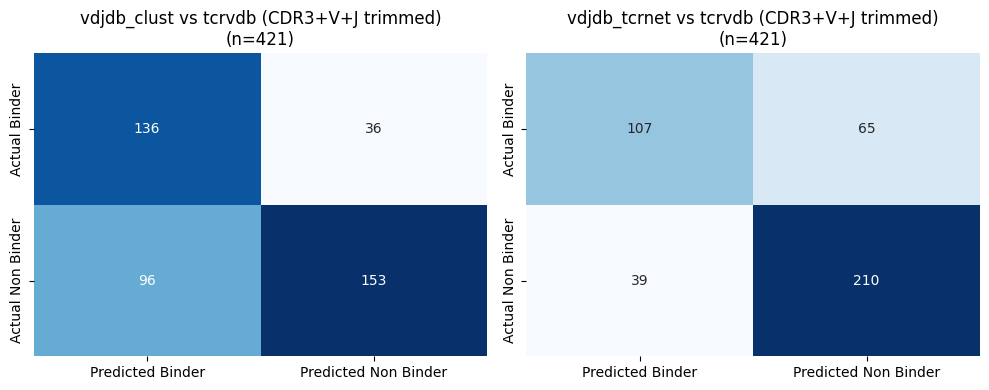

In [100]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

def trim_allele(gene):
    """Удаляет часть после звёздочки: TRBV28*01 -> TRBV28"""
    if pd.isna(gene):
        return gene
    return re.sub(r'\*.*$', '', gene)

def confusion_summary_vj_trimmed(tcrvdb, other_df, cols_other):
    """
    Строит TP/FP/FN/TN для таблицы tcrvdb против другой таблицы,
    учитывая совпадение по CDR3 + V + J (с обрезкой аллелей)
    cols_other — словарь с ключами 'cdr3', 'v', 'j'
    """
    df = tcrvdb.copy()
    df['V_trim'] = df['TRBV'].apply(trim_allele)
    df['J_trim'] = df['TRBJ'].apply(trim_allele)
    df['key'] = df['cdr3_beta_aa'] + '|' + df['V_trim'] + '|' + df['J_trim']

    other_df = other_df.copy()
    other_df['V_trim'] = other_df[cols_other['v']].apply(trim_allele)
    other_df['J_trim'] = other_df[cols_other['j']].apply(trim_allele)
    other_df['key'] = (
        other_df[cols_other['cdr3']] + '|' +
        other_df['V_trim'] + '|' +
        other_df['J_trim']
    )

    df['in_other'] = df['key'].isin(other_df['key'])

    df['category'] = df.apply(
        lambda r: 'TP' if r['in_other'] and r['valid']
        else 'FP' if r['in_other'] and not r['valid']
        else 'FN' if not r['in_other'] and r['valid']
        else 'TN',
        axis=1
    )
    return df['category'].value_counts().reindex(['TP', 'FP', 'FN', 'TN'], fill_value=0)

vdjdb_clust = merged_data[
    merged_data['antigen.epitope'].str.startswith('YLQ')][
    ['vdjdb_id', 'cdr3aa_beta', 'v_beta', 'j_beta', 'antigen.epitope']]

# === 1. для vdjdb_clust ===
summary_clust = confusion_summary_vj_trimmed(
    tcrvdb[tcrvdb['epitope_aa'].str.startswith('YLQ')], 
    vdjdb_clust, 
    cols_other={'cdr3': 'cdr3aa_beta', 'v': 'v_beta', 'j': 'j_beta'}
)

# === 2. для vdjdb_tcrnet ===

vdjdb_tcrnet = motifs[motifs['antigen.epitope'].str.startswith('YLQ')][['cdr3aa', 'v.segm', 'j.segm', 'antigen.epitope']]

summary_tcrnet = confusion_summary_vj_trimmed(
    tcrvdb[tcrvdb['epitope_aa'].str.startswith('YLQ')],
    vdjdb_tcrnet,
    cols_other={'cdr3': 'cdr3aa', 'v': 'v.segm', 'j': 'j.segm'}
)

# === 3. рисуем две heatmap рядом ===
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

def draw_heatmap(summary, ax, title):
    total = summary.sum()
    data = [[summary['TP'], summary['FN']],
            [summary['FP'], summary['TN']]]
    sns.heatmap(data, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Predicted Binder', 'Predicted Non Binder'],
                yticklabels=['Actual Binder', 'Actual Non Binder'], ax=ax)
    ax.set_title(title + f"\n(n={total})")

draw_heatmap(summary_clust, axes[0], "vdjdb_clust vs tcrvdb (CDR3+V+J trimmed)")
draw_heatmap(summary_tcrnet, axes[1], "vdjdb_tcrnet vs tcrvdb (CDR3+V+J trimmed)")

plt.tight_layout()
plt.show()



=== YLQ ===


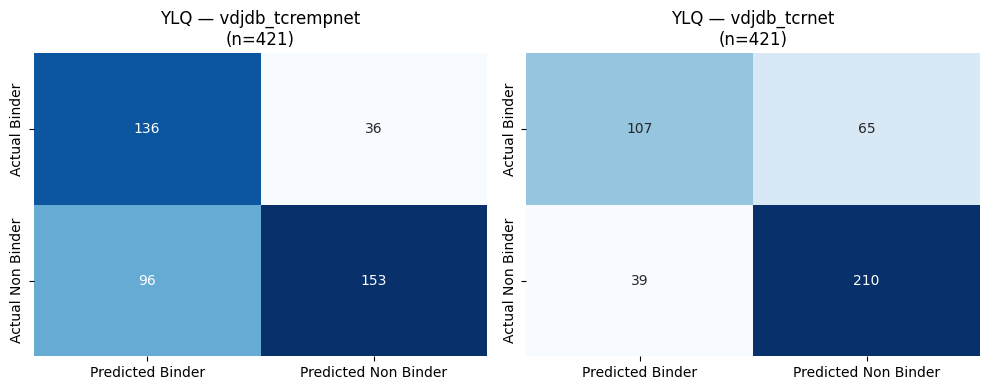


YLQ metrics:
vdjdb_clust:
 precision    0.586207
recall       0.790698
f1           0.673267
dtype: float64
vdjdb_tcrnet:
 precision    0.732877
recall       0.622093
f1           0.672956
dtype: float64


In [113]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

def trim_allele(gene):
    """Удаляет часть после звёздочки: TRBV28*01 -> TRBV28"""
    if pd.isna(gene):
        return gene
    return re.sub(r'\*.*$', '', gene)

def confusion_summary_vj_trimmed(tcrvdb, other_df, cols_other):
    """
    Строит TP/FP/FN/TN и метрики precision, recall, F1
    с учётом совпадения по CDR3 + V + J (обрезая аллели)
    """
    df = tcrvdb.copy()
    df['V_trim'] = df['TRBV'].apply(trim_allele)
    df['J_trim'] = df['TRBJ'].apply(trim_allele)
    df['key'] = df['cdr3_beta_aa'] + '|' + df['V_trim'] + '|' + df['J_trim']

    other_df = other_df.copy()
    other_df['V_trim'] = other_df[cols_other['v']].apply(trim_allele)
    other_df['J_trim'] = other_df[cols_other['j']].apply(trim_allele)
    other_df['key'] = (
        other_df[cols_other['cdr3']] + '|' +
        other_df['V_trim'] + '|' +
        other_df['J_trim']
    )

    df['in_other'] = df['key'].isin(other_df['key'])

    df['category'] = df.apply(
        lambda r: 'TP' if r['in_other'] and r['valid']
        else 'FP' if r['in_other'] and not r['valid']
        else 'FN' if not r['in_other'] and r['valid']
        else 'TN',
        axis=1
    )

    summary = df['category'].value_counts().reindex(['TP', 'FP', 'FN', 'TN'], fill_value=0)

    # Метрики
    TP, FP, FN, TN = summary['TP'], summary['FP'], summary['FN'], summary['TN']
    precision = TP / (TP + FP) if (TP + FP) else 0
    recall = TP / (TP + FN) if (TP + FN) else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0

    metrics = pd.Series({
        'precision': precision,
        'recall': recall,
        'f1': f1
    })

    return summary, metrics


def draw_heatmap(summary, ax, title):
    total = summary.sum()
    data = [[summary['TP'], summary['FN']],
            [summary['FP'], summary['TN']]]
    sns.heatmap(data, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Predicted Binder', 'Predicted Non Binder'],
                yticklabels=['Actual Binder', 'Actual Non Binder'], ax=ax)
    ax.set_title(title + f"\n(n={total})")


# === Анализ для двух эпитопов ===
epitopes = ['YLQ']
results = {}

for epi in epitopes:
    print(f"\n=== {epi} ===")

    # Фильтруем данные
    tcrvdb_epi = tcrvdb[tcrvdb['epitope_aa'].str.startswith(epi)]
    vdjdb_clust_epi = merged_data[merged_data['antigen.epitope'].str.startswith(epi)][
        ['vdjdb_id', 'cdr3aa_beta', 'v_beta', 'j_beta', 'antigen.epitope']
    ]
    vdjdb_tcrnet_epi = motifs[motifs['antigen.epitope'].str.startswith(epi)][
        ['cdr3aa', 'v.segm', 'j.segm', 'antigen.epitope']
    ]

    # Вычисляем confusion matrix и метрики
    summary_clust, metrics_clust = confusion_summary_vj_trimmed(
        tcrvdb_epi, vdjdb_clust_epi,
        cols_other={'cdr3': 'cdr3aa_beta', 'v': 'v_beta', 'j': 'j_beta'}
    )
    summary_tcrnet, metrics_tcrnet = confusion_summary_vj_trimmed(
        tcrvdb_epi, vdjdb_tcrnet_epi,
        cols_other={'cdr3': 'cdr3aa', 'v': 'v.segm', 'j': 'j.segm'}
    )

    # Сохраняем результаты
    results[epi] = {
        'clust': (summary_clust, metrics_clust),
        'tcrnet': (summary_tcrnet, metrics_tcrnet)
    }

# === Визуализация ===
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for i, epi in enumerate(epitopes):
    summary_clust, _ = results[epi]['clust']
    summary_tcrnet, _ = results[epi]['tcrnet']

    draw_heatmap(summary_clust, axes[0], f"{epi} — vdjdb_tcrempnet")
    draw_heatmap(summary_tcrnet, axes[1], f"{epi} — vdjdb_tcrnet")

plt.tight_layout()
plt.show()

# === Печать метрик ===
for epi in epitopes:
    print(f"\n{epi} metrics:")
    print("vdjdb_clust:\n", results[epi]['clust'][1])
    print("vdjdb_tcrnet:\n", results[epi]['tcrnet'][1])


In [102]:
tcrvdb_YLQ = tcrvdb[tcrvdb.epitope_aa == 'YLQPRTFLL']

In [103]:
vdjdb_clust = merged_data[
    merged_data['antigen.epitope'].str.startswith('YLQ')][
    ['vdjdb_id', 'cdr3aa_beta', 'v_beta', 'j_beta', 'antigen.epitope', 'cluster_id']]
vdjdb_clust

,vdjdb_id,cdr3aa_beta,v_beta,j_beta,antigen.epitope,cluster_id
0,3863,CSARDEKATNTGELFF,TRBV20-1*01,TRBJ2-2*01,YLQPRTFLL,0
1,3864,CASMEENTGELFF,TRBV5-1*01,TRBJ2-2*01,YLQPRTFLL,1
2,3867,CATQTANTGELFF,TRBV24-1*01,TRBJ2-2*01,YLQPRTFLL,3
3,3868,CASSELNTGELFF,TRBV2*01,TRBJ2-2*01,YLQPRTFLL,4
4,3869,CATQTANTGELFF,TRBV24-1*01,TRBJ2-2*01,YLQPRTFLL,3
...,...,...,...,...,...,...
702,102971,CASRHMGTGFYNEQFF,TRBV28*01,TRBJ2-1*01,YLQPRTFLL,211
703,102975,CASSSANSGELFF,TRBV7-9*01,TRBJ2-2*01,YLQPRTFLL,13
704,102976,CATTELDTGELFF,TRBV15*01,TRBJ2-2*01,YLQPRTFLL,24
705,102977,CASRGLAEMNTGELFF,TRBV2*01,TRBJ2-2*01,YLQPRTFLL,98


In [104]:
import pandas as pd
import re

def trim_allele(gene):
    """Удаляет часть после звёздочки: TRBV28*01 -> TRBV28"""
    if pd.isna(gene):
        return gene
    return re.sub(r'\*.*$', '', gene)

def prepare_keys(df, cdr3_col, v_col, j_col):
    """Создаёт колонку 'key' = CDR3|V|J (с обрезкой аллелей)"""
    out = df.copy()
    out['V_trim'] = out[v_col].apply(trim_allele)
    out['J_trim'] = out[j_col].apply(trim_allele)
    out['key'] = out[cdr3_col] + '|' + out['V_trim'] + '|' + out['J_trim']
    return out


# === создаём ключи ===
tcrvdb_YLQ_keys = prepare_keys(tcrvdb_YLQ, 'cdr3_beta_aa', 'TRBV', 'TRBJ')
clust_keys       = prepare_keys(vdjdb_clust, 'cdr3aa_beta', 'v_beta', 'j_beta')

# === метим совпадения ===
tcrvdb_YLQ_keys['in_clust'] = tcrvdb_YLQ_keys['key'].isin(clust_keys['key'])

# === классификация (как в heatmap) ===
tcrvdb_YLQ_keys['category'] = tcrvdb_YLQ_keys.apply(
    lambda r: 'TP' if r['in_clust'] and r['valid']
    else 'FP' if r['in_clust'] and not r['valid']
    else 'FN' if not r['in_clust'] and r['valid']
    else 'TN',
    axis=1
)

# --- добавляем cluster_id через merge (только для TP/FP/FN где есть в clust_keys) ---
tcrvdb_YLQ_keys = tcrvdb_YLQ_keys.merge(
    clust_keys[['key', 'cluster_id']],
    on='key',
    how='left'
)

# --- теперь выделяем только несовпадения (FP + FN) ---
mismatch = tcrvdb_YLQ_keys[tcrvdb_YLQ_keys['category'].isin(['FP', 'FN'])]

print(f"Несовпадений (FP + FN) между vdjdb_clust и tcrvdb_YLQ: {len(mismatch)}")

# --- выводим информативные колонки ---
cols_to_show = [
    'cluster_id', 'cdr3_beta_aa', 'TRBV', 'TRBJ',
    'epitope_aa', 'valid', 'category'
]
display(mismatch[cols_to_show].head(20))


Несовпадений (FP + FN) между vdjdb_clust и tcrvdb_YLQ: 181


,cluster_id,cdr3_beta_aa,TRBV,TRBJ,epitope_aa,valid,category
6,6.0,CASSHDIEAFF,TRBV7-9,TRBJ1-1,YLQPRTFLL,False,FP
8,NaN,CASSESNSLEAFF,TRBV25-1,TRBJ1-1,YLQPRTFLL,True,FN
22,11.0,CSAHRDRNTGELFF,TRBV20-1,TRBJ2-2,YLQPRTFLL,False,FP
25,20.0,CSVEADRNTGELFF,TRBV29-1,TRBJ2-2,YLQPRTFLL,False,FP
26,44.0,CSAGDLNTGELFF,TRBV20-1,TRBJ2-2,YLQPRTFLL,False,FP
27,44.0,CSAGDLNTGELFF,TRBV20-1,TRBJ2-2,YLQPRTFLL,False,FP
28,13.0,CAGGEPNTGELFF,TRBV7-9,TRBJ2-2,YLQPRTFLL,False,FP
30,9.0,CASQTLNTGELFF,TRBV19,TRBJ2-2,YLQPRTFLL,False,FP
31,47.0,CASTRDLNTGELFF,TRBV2,TRBJ2-2,YLQPRTFLL,False,FP
32,NaN,CASSLETAGEQYF,TRBV28,TRBJ2-7,YLQPRTFLL,True,FN


In [134]:
mismatch[mismatch.cluster_id == 0]

,name,clonotype_aa,cdr3_alpha_aa,cdr3_beta_aa,TRAV,TRAJ,TRBV,TRBJ,TRBD,TRAV_IMGT,...,stat,pvalue,padj,valid,V_trim,J_trim,key,in_clust,category,cluster_id
34,1_6_G5_76_YLQPRTFLL,TRAV12-1_CVVNEYDDMRF_TRAJ43--TRBV20-1_CSARDAAG...,CVVNEYDDMRF,CSARDAAGQNTGELFF,TRAV12-1,TRAJ43,TRBV20-1,TRBJ2-2,NaN,TRAV12-1*01,...,-2.398745,0.016451,0.092908,False,TRBV20-1,TRBJ2-2,CSARDAAGQNTGELFF|TRBV20-1|TRBJ2-2,True,FP,0.0
148,1_4_G20_175_YLQPRTFLL,TRAV8-6_CAVLPHGNNRLAF_TRAJ7--TRBV20-1_CSARDRVG...,CAVLPHGNNRLAF,CSARDRVGQNTGELFF,TRAV8-6,TRAJ7,TRBV20-1,TRBJ2-2,TRBD1,TRAV8-6*01,...,-0.569517,0.569005,1.000000,False,TRBV20-1,TRBJ2-2,CSARDRVGQNTGELFF|TRBV20-1|TRBJ2-2,True,FP,0.0
255,1_5_B15_110_YLQPRTFLL,TRAV12-1_CVVNAPSGNTPLVF_TRAJ29--TRBV20-1_CSARD...,CVVNAPSGNTPLVF,CSARDLGAQNTGELFF,TRAV12-1,TRAJ29,TRBV20-1,TRBJ2-2,NaN,TRAV12-1*01,...,-4.718745,0.000002,0.000021,False,TRBV20-1,TRBJ2-2,CSARDLGAQNTGELFF|TRBV20-1|TRBJ2-2,True,FP,0.0
260,1_5_C6_29_YLQPRTFLL,TRAV12-1_CVVNIPAGNTPLVF_TRAJ29--TRBV20-1_CSARD...,CVVNIPAGNTPLVF,CSARDHGATNTGELFF,TRAV12-1,TRAJ29,TRBV20-1,TRBJ2-2,NaN,TRAV12-1*01,...,-0.596868,0.550595,1.000000,False,TRBV20-1,TRBJ2-2,CSARDHGATNTGELFF|TRBV20-1|TRBJ2-2,True,FP,0.0
352,1_5_A12_11_YLQPRTFLL,TRAV9-2_CALSENKLSF_TRAJ20--TRBV20-1_CSARDPTQQN...,CALSENKLSF,CSARDPTQQNTGELFF,TRAV9-2,TRAJ20,TRBV20-1,TRBJ2-2,TRBD1,TRAV9-2*01,...,0.218116,0.827339,1.000000,False,TRBV20-1,TRBJ2-2,CSARDPTQQNTGELFF|TRBV20-1|TRBJ2-2,True,FP,0.0
354,1_5_A11_10_YLQPRTFLL,TRAV14/DV4_CARDQRGYQKVTF_TRAJ13--TRBV20-1_CSAR...,CARDQRGYQKVTF,CSARDDRALNTGELFF,TRAV14/DV4,TRAJ13,TRBV20-1,TRBJ2-2,TRBD1,TRAV14_DV4*01,...,-0.016967,0.986463,1.000000,False,TRBV20-1,TRBJ2-2,CSARDDRALNTGELFF|TRBV20-1|TRBJ2-2,True,FP,0.0
422,1_5_B6_17_YLQPRTFLL,TRAV8-1_CAVNPPSGTYKYIF_TRAJ40--TRBV20-1_CSARDK...,CAVNPPSGTYKYIF,CSARDKQGWNTGELFF,TRAV8-1,TRAJ40,TRBV20-1,TRBJ2-2,TRBD1,TRAV8-1*01,...,-0.746874,0.455140,1.000000,False,TRBV20-1,TRBJ2-2,CSARDKQGWNTGELFF|TRBV20-1|TRBJ2-2,True,FP,0.0
476,1_5_F13_156_YLQPRTFLL,TRAV12-1_CVVNAPSGNTPLVF_TRAJ29--TRBV20-1_CSARG...,CVVNAPSGNTPLVF,CSARGEVEMNTGELFF,TRAV12-1,TRAJ29,TRBV20-1,TRBJ2-2,NaN,TRAV12-1*01,...,-2.542628,0.011002,0.065139,False,TRBV20-1,TRBJ2-2,CSARGEVEMNTGELFF|TRBV20-1|TRBJ2-2,True,FP,0.0
544,1_5_D10_45_YLQPRTFLL,TRAV12-1_CVVNAPSGNTPLVF_TRAJ29--TRBV20-1_CSARD...,CVVNAPSGNTPLVF,CSARDLAGMNTGELFF,TRAV12-1,TRAJ29,TRBV20-1,TRBJ2-2,NaN,TRAV12-1*01,...,-4.577642,0.000005,0.000041,False,TRBV20-1,TRBJ2-2,CSARDLAGMNTGELFF|TRBV20-1|TRBJ2-2,True,FP,0.0
649,1_6_A16_99_YLQPRTFLL,TRAV1-2_CAGPPNKLIF_TRAJ4--TRBV20-1_CSARDPRAQNT...,CAGPPNKLIF,CSARDPRAQNTGELFF,TRAV1-2,TRAJ4,TRBV20-1,TRBJ2-2,NaN,TRAV1-2*01,...,0.109277,0.912983,1.000000,False,TRBV20-1,TRBJ2-2,CSARDPRAQNTGELFF|TRBV20-1|TRBJ2-2,True,FP,0.0


In [137]:
pat = tcrvdb[tcrvdb.cdr3_beta_aa.str.match('CSAR.....NTGELFF')]

In [139]:
pat[['TRAV_IMGT', 'valid']]

,TRAV_IMGT,valid
21,TRAV12-1*01,False
40,TRAV12-1*01,True
106,TRAV8-6*01,False
172,TRAV12-1*01,False
177,TRAV12-1*01,False
183,TRAV12-1*01,True
191,TRAV12-1*01,True
192,TRAV12-1*01,True
204,TRAV9-2*01,False
206,TRAV14_DV4*01,False


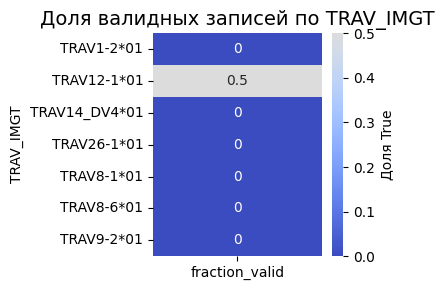

In [144]:
heatmap_frac = pat.groupby('TRAV_IMGT')['valid'].mean().to_frame('fraction_valid')

plt.figure(figsize=(4, 3))
sns.heatmap(
    heatmap_frac,
    annot=True,
    cmap='coolwarm',
    center=0.5,
    cbar_kws={'label': 'Доля True'}
)

plt.title("Доля валидных записей по TRAV_IMGT", fontsize=14)
plt.xlabel("")
plt.ylabel("TRAV_IMGT")
plt.tight_layout()
plt.show()


In [105]:
mismatch[cols_to_show].cluster_id.value_counts()

cluster_id
6.0        38
0.0        12
103.0       8
4.0         7
13.0        5
10.0        4
105.0       4
47.0        3
11.0        3
44.0        3
38.0        3
100.0       2
72.0        2
9.0         2
20.0        2
3.0         2
28.0        2
25.0        2
141.0       1
82.0        1
115.0       1
99.0        1
136.0       1
114.0       1
158.0       1
142.0       1
16908.0     1
84.0        1
94.0        1
8.0         1
98.0        1
124.0       1
42.0        1
102.0       1
34.0        1
116.0       1
16.0        1
125.0       1
55.0        1
107.0       1
110.0       1
2166.0      1
147.0       1
19595.0     1
156.0       1
121.0       1
120.0       1
19542.0     1
130.0       1
68.0        1
30.0        1
164.0       1
62.0        1
67.0        1
93.0        1
40.0        1
131.0       1
60.0        1
1716.0      1
Name: count, dtype: int64

In [106]:
mismatch[cols_to_show].cluster_id.unique()

array([6.0000e+00,        nan, 1.1000e+01, 2.0000e+01, 4.4000e+01,
       1.3000e+01, 9.0000e+00, 4.7000e+01, 0.0000e+00, 1.4100e+02,
       1.0000e+01, 1.1400e+02, 1.6908e+04, 1.1500e+02, 1.5800e+02,
       1.4200e+02, 8.2000e+01, 1.0500e+02, 1.0300e+02, 7.2000e+01,
       1.3600e+02, 1.0000e+02, 9.9000e+01, 9.8000e+01, 4.0000e+00,
       8.0000e+00, 9.4000e+01, 8.4000e+01, 3.4000e+01, 4.2000e+01,
       1.0200e+02, 1.4700e+02, 1.2400e+02, 1.2500e+02, 1.6000e+01,
       1.1600e+02, 5.5000e+01, 2.8000e+01, 1.0700e+02, 2.5000e+01,
       3.0000e+00, 1.1000e+02, 2.1660e+03, 1.9595e+04, 1.5600e+02,
       1.2000e+02, 1.2100e+02, 3.0000e+01, 1.9542e+04, 1.3000e+02,
       6.8000e+01, 1.6400e+02, 6.2000e+01, 9.3000e+01, 6.7000e+01,
       4.0000e+01, 3.8000e+01, 1.3100e+02, 6.0000e+01, 1.7160e+03])

In [145]:
enriched[enriched.cluster_id == 103]#.cdr3aa_beta.str.len().hist()

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,source,enrichment_pvalue_zbinom,vdjdb_id
180323,s_88159,103,CASSPMGNWGNQPQHF,TRBV2*01,TRBJ1-5*01,sample,0.0,88159
180324,s_88160,103,CASSPMGNWGNQPQHF,TRBV2*01,TRBJ1-5*01,sample,0.0,88160
180325,s_88161,103,CASSPMGNWGNQPQHF,TRBV2*01,TRBJ1-5*01,sample,0.0,88161
180326,s_88164,103,CASSPMGNWGNQPQHF,TRBV2*01,TRBJ1-5*01,sample,0.0,88164


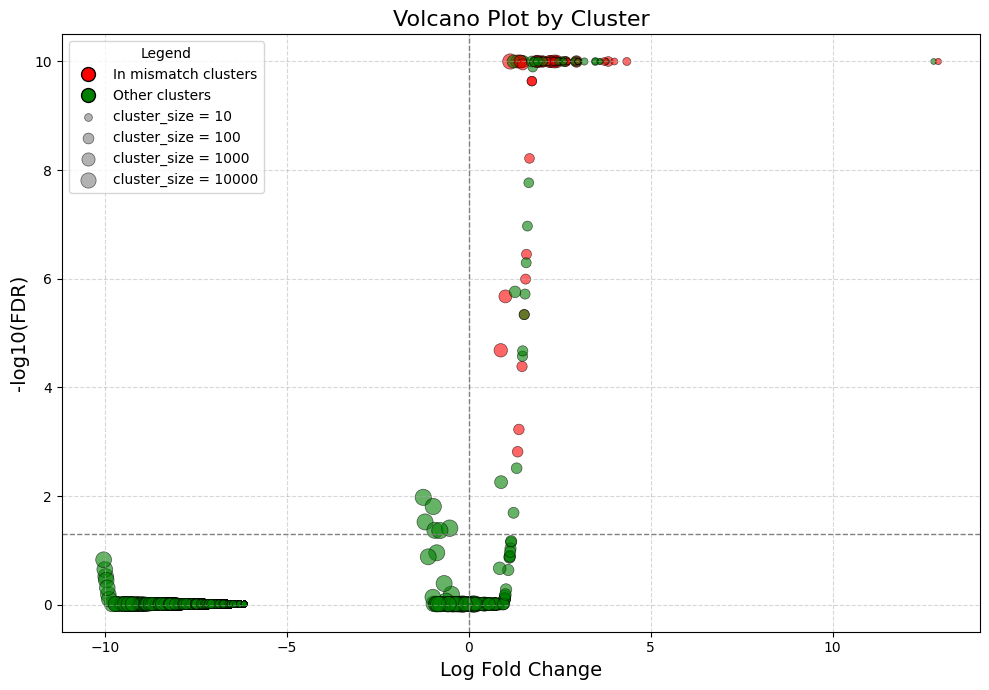

In [108]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Копия датафрейма
df = info.copy()
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["enrichment_fdr_zbinom", "log_fold_change"])

# === Список кластеров для подсветки ===
target_clusters = set(mismatch[cols_to_show].cluster_id.unique())

# === Цвета по условию ===
df["color"] = np.where(df["cluster_id"].isin(target_clusters), "red", "green")

# === Параметры ===
x = df["log_fold_change"]
y = -np.log10(df["enrichment_fdr_zbinom"] + 1e-10)
sizes = np.log10(df["cluster_size"] + 1) * 30
colors = df["color"]

# === Построение ===
plt.figure(figsize=(10, 7))
plt.scatter(x, y, s=sizes, c=colors, alpha=0.6, edgecolors="black", linewidths=0.5)

# === Оформление ===
plt.xlabel("Log Fold Change", fontsize=14)
plt.ylabel("-log10(FDR)", fontsize=14)
plt.title("Volcano Plot by Cluster", fontsize=16)
plt.axhline(y=-np.log10(0.05), color="gray", linestyle="--", linewidth=1)
plt.axvline(x=0, color="gray", linestyle="--", linewidth=1)
plt.grid(True, linestyle="--", alpha=0.5)

# === Легенда по цветам ===
color_handles = [
    Line2D([0], [0], marker="o", color="w", label="In mismatch clusters", markerfacecolor="red", markersize=10, markeredgecolor="black"),
    Line2D([0], [0], marker="o", color="w", label="Other clusters", markerfacecolor="green", markersize=10, markeredgecolor="black"),
]

# === Легенда по размерам кластера ===
legend_sizes = [10, 100, 1000, 10000]
size_handles = [
    plt.scatter([], [], s=np.log10(s + 1) * 30, color="gray", alpha=0.6, edgecolors="black", linewidths=0.5)
    for s in legend_sizes
]

# === Объединяем легенды ===
plt.legend(
    handles=color_handles + size_handles,
    labels=["In mismatch clusters", "Other clusters"] + [f"cluster_size = {s}" for s in legend_sizes],
    title="Legend",
    loc="best",
    frameon=True
)

plt.tight_layout()
plt.show()


In [122]:
info[info.cluster_id == 0]

,cluster_id,cluster_size,sample,background,enrichment_pvalue_zbinom,enrichment_fdr_zbinom,log_fold_change
0,0,642,73,569,0.0,0.0,2.40854


In [123]:
enriched[enriched.cluster_id == 0]

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,source,enrichment_pvalue_zbinom,vdjdb_id
0,s_3863,0,CSARDEKATNTGELFF,TRBV20-1*01,TRBJ2-2*01,sample,0.0,3863
1,s_6163,0,CSARTPMGQNTGELFF,TRBV20-1*01,TRBJ2-2*01,sample,0.0,6163
2,s_6177,0,CSARDLAGMNTGELFF,TRBV20-1*01,TRBJ2-2*01,sample,0.0,6177
3,s_6181,0,CSARDAGGQNTGELFF,TRBV20-1*01,TRBJ2-2*01,sample,0.0,6181
4,s_6209,0,CSARDQASQNTGELFF,TRBV20-1*01,TRBJ2-2*01,sample,0.0,6209
...,...,...,...,...,...,...,...,...
68,s_102839,0,CSARDRGATNTGELFF,TRBV20-1*01,TRBJ2-2*01,sample,0.0,102839
69,s_102911,0,CSARDREQQNTGELFF,TRBV20-1*01,TRBJ2-2*01,sample,0.0,102911
70,s_102923,0,CSARDRLAENTGELFF,TRBV20-1*01,TRBJ2-2*01,sample,0.0,102923
71,s_102944,0,CSARDAAATNTGELFF,TRBV20-1*01,TRBJ2-2*01,sample,0.0,102944


In [131]:
enriched[enriched.cluster_id == 0].cdr3aa_beta

0     CSARDEKATNTGELFF
1     CSARTPMGQNTGELFF
2     CSARDLAGMNTGELFF
3     CSARDAGGQNTGELFF
4     CSARDQASQNTGELFF
            ...       
68    CSARDRGATNTGELFF
69    CSARDREQQNTGELFF
70    CSARDRLAENTGELFF
71    CSARDAAATNTGELFF
72    CSARDHVGQNTGELFF
Name: cdr3aa_beta, Length: 73, dtype: object

In [124]:
enriched[enriched.cluster_id == 0].cdr3aa_beta.nunique()

68

In [128]:
motifs[motifs.cdr3aa.isin(enriched[enriched.cluster_id == 0].cdr3aa_beta)]#.cdr3aa.nunique()

,species,antigen.epitope,antigen.gene,antigen.species,mhc.a,mhc.b,mhc.class,gene,cdr3aa,x,y,cid,csz,v.segm,j.segm,v.end,j.start,v.segm.repr,j.segm.repr
34193,HomoSapiens,YLQPRTFLL,Spike,SARS-CoV-2,HLA-A*02:01,B2M,MHCI,TRB,CSARDERALNTGELFF,971.057269,936.022532,H.B.YLQPRTFLL.21,16,TRBV20-1*01,TRBJ2-2*01,4,9,TRBV20-1*01,TRBJ2-2*01
34194,HomoSapiens,YLQPRTFLL,Spike,SARS-CoV-2,HLA-A*02:01,B2M,MHCI,TRB,CSARDERAVNTGELFF,931.199498,991.429630,H.B.YLQPRTFLL.21,16,TRBV20-1*01,TRBJ2-2*01,4,9,TRBV20-1*01,TRBJ2-2*01
34195,HomoSapiens,YLQPRTFLL,Spike,SARS-CoV-2,HLA-A*02:01,B2M,MHCI,TRB,CSARDGLAMNTGELFF,1291.170057,471.324098,H.B.YLQPRTFLL.21,16,TRBV20-1*01,TRBJ2-2*01,4,9,TRBV20-1*01,TRBJ2-2*01
34196,HomoSapiens,YLQPRTFLL,Spike,SARS-CoV-2,HLA-A*02:01,B2M,MHCI,TRB,CSARDGLAQNTGELFF,1292.798389,563.369884,H.B.YLQPRTFLL.21,16,TRBV20-1*01,TRBJ2-2*01,4,9,TRBV20-1*01,TRBJ2-2*01
34197,HomoSapiens,YLQPRTFLL,Spike,SARS-CoV-2,HLA-A*02:01,B2M,MHCI,TRB,CSARDGQAMNTGELFF,1284.804660,395.557922,H.B.YLQPRTFLL.21,16,TRBV20-1*01,TRBJ2-2*01,4,9,TRBV20-1*01,TRBJ2-2*01
34198,HomoSapiens,YLQPRTFLL,Spike,SARS-CoV-2,HLA-A*02:01,B2M,MHCI,TRB,CSARDGQGMNTGELFF,1273.065436,329.995692,H.B.YLQPRTFLL.21,16,TRBV20-1*01,TRBJ2-2*01,4,9,TRBV20-1*01,TRBJ2-2*01
34199,HomoSapiens,YLQPRTFLL,Spike,SARS-CoV-2,HLA-A*02:01,B2M,MHCI,TRB,CSARDHVGQNTGELFF,667.910576,1444.285306,H.B.YLQPRTFLL.24,11,TRBV20-1*01,TRBJ2-2*01,4,9,TRBV20-1*01,TRBJ2-2*01
34200,HomoSapiens,YLQPRTFLL,Spike,SARS-CoV-2,HLA-A*02:01,B2M,MHCI,TRB,CSARDLAAQNTGELFF,117.058084,1311.558360,H.B.YLQPRTFLL.24,11,TRBV20-1*01,TRBJ2-2*01,4,9,TRBV20-1*01,TRBJ2-2*01
34201,HomoSapiens,YLQPRTFLL,Spike,SARS-CoV-2,HLA-A*02:01,B2M,MHCI,TRB,CSARDLGAQNTGELFF,48.657415,1324.580496,H.B.YLQPRTFLL.24,11,TRBV20-1*01,TRBJ2-2*01,4,9,TRBV20-1*01,TRBJ2-2*01
34202,HomoSapiens,YLQPRTFLL,Spike,SARS-CoV-2,HLA-A*02:01,B2M,MHCI,TRB,CSARDPRAQNTGELFF,1143.007885,802.177766,H.B.YLQPRTFLL.21,16,TRBV20-1*01,TRBJ2-2*01,4,9,TRBV20-1*01,TRBJ2-2*01


In [146]:
motifs[motifs.cdr3aa == 'CASSPMGNWGNQPQHF']

,species,antigen.epitope,antigen.gene,antigen.species,mhc.a,mhc.b,mhc.class,gene,cdr3aa,x,y,cid,csz,v.segm,j.segm,v.end,j.start,v.segm.repr,j.segm.repr
